In [5]:
# 데이터를 저장할 폴더 생성 및 다운로드
#!mkdir data
#!wget https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/data/pyLikelihood/L1504241622054B65347F25_PH00.fits -P data/
#!wget https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/data/pyLikelihood/L1504241622054B65347F25_PH01.fits -P data/
#!wget https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/data/pyLikelihood/L1504241622054B65347F25_SC00.fits -P data/

# 위성 상태 파일 이름 변경 (편의상)
#!mv data/*SC00.fits data/PG1553_SC.fits

# 관측(Event) FITS 파일들의 목록 리스트 생성
#!ls ./data/*PH*.fits > ./data/PG1553_events.list

## Perform Event Selections

In [6]:
import gt_apps as my_apps
import gc

In [7]:
my_apps.filter['evclass'] = 128
my_apps.filter['evtype'] = 3
my_apps.filter['ra'] = 238.929
my_apps.filter['dec'] = 11.1901
my_apps.filter['rad'] = 10
my_apps.filter['emin'] = 100
my_apps.filter['emax'] = 300000
my_apps.filter['zmax'] = 90
my_apps.filter['tmin'] = 239557417
my_apps.filter['tmax'] = 256970880
my_apps.filter['infile'] = '@./data/PG1553_events.list'
my_apps.filter['outfile'] = './data/PG1553_filtered.fits'

In [8]:
my_apps.filter.run()

time -p gtselect infile=@./data/PG1553_events.list outfile=./data/PG1553_filtered.fits ra=238.929 dec=11.1901 rad=10.0 tmin=239557417.0 tmax=256970880.0 emin=100.0 emax=300000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 0.36
user 0.33
sys 0.03


In [9]:
my_apps.filter.command()

'time -p gtselect infile=@./data/PG1553_events.list outfile=./data/PG1553_filtered.fits ra=238.929 dec=11.1901 rad=10.0 tmin=239557417.0 tmax=256970880.0 emin=100.0 emax=300000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"'

In [10]:
import gt_apps as my_apps

my_apps.maketime['scfile'] = './data/PG1553_SC.fits'
my_apps.maketime['filter'] = '(DATA_QUAL>0)&&(LAT_CONFIG==1)'
my_apps.maketime['roicut'] = 'no'
my_apps.maketime['evfile'] = './data/PG1553_filtered.fits' # gtselect의 결과물
my_apps.maketime['outfile'] = './data/PG1553_filtered_gti.fits'

In [11]:
my_apps.maketime.run()

time -p gtmktime scfile=./data/PG1553_SC.fits sctable="SC_DATA" filter="(DATA_QUAL>0)&&(LAT_CONFIG==1)" roicut=no evfile=./data/PG1553_filtered.fits evtable="EVENTS" outfile="./data/PG1553_filtered_gti.fits" apply_filter=yes overwrite=no header_obstimes=yes tstart=0.0 tstop=0.0 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 0.46
user 0.35
sys 0.09


## Livetime Cubes and Exposure Maps

In [12]:
#!wget http://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/data/pyLikelihood/PG1553_ltCube.fits
#!mv *.fits ./data

In [13]:
my_apps.expCube['evfile'] = './data/PG1553_filtered_gti.fits'
my_apps.expCube['scfile'] = './data/PG1553_SC.fits'
my_apps.expCube['outfile'] = './data/PG1553_ltCube.fits'
my_apps.expCube['zmax'] = 90
my_apps.expCube['dcostheta'] = 0.025
my_apps.expCube['binsz'] = 1

In [14]:
my_apps.expCube.run()

time -p gtltcube evfile="./data/PG1553_filtered_gti.fits" evtable="EVENTS" scfile=./data/PG1553_SC.fits sctable="SC_DATA" outfile=./data/PG1553_ltCube.fits dcostheta=0.025 binsz=1.0 phibins=0 tmin=0.0 tmax=0.0 file_version="1" zmin=0.0 zmax=90.0 chatter=2 clobber=yes debug=no gui=no mode="ql"
Working on file ./data/PG1553_SC.fits
.....................!
real 391.23
user 390.29
sys 0.16


In [15]:
from GtApp import GtApp
expCubeSun = GtApp('gtltcubesun','Likelihood')
expCubeSun.command()

'time -p gtltcubesun evfile="" evtable="EVENTS" scfile= sctable="SC_DATA" outfile=expCube.fits body="SUN" dcostheta=0.025 thetasunmax=180.0 binsz=0.5 phibins=0 tmin=0.0 tmax=0.0 powerbinsun=2.7 file_version="1" zmax=180.0 chatter=2 clobber=yes debug=no gui=no mode="ql"'

In [16]:
my_apps.expMap['evfile'] = './data/PG1553_filtered_gti.fits'
my_apps.expMap['scfile'] = './data/PG1553_SC.fits'
my_apps.expMap['expcube'] = './data/PG1553_ltCube.fits'
my_apps.expMap['outfile'] = './data/PG1553_expMap.fits'
my_apps.expMap['irfs'] = 'CALDB'
my_apps.expMap['srcrad'] = 20
my_apps.expMap['nlong'] = 120
my_apps.expMap['nlat'] = 120
my_apps.expMap['nenergies'] = 37

In [17]:
my_apps.expMap.run()

time -p gtexpmap evfile=./data/PG1553_filtered_gti.fits evtable="EVENTS" scfile=./data/PG1553_SC.fits sctable="SC_DATA" expcube=./data/PG1553_ltCube.fits outfile=./data/PG1553_expMap.fits irfs="CALDB" evtype="INDEF" srcrad=20.0 nlong=120 nlat=120 nenergies=37 submap=no nlongmin=0 nlongmax=0 nlatmin=0 nlatmax=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
The exposure maps generated by this tool are meant
to be used for *unbinned* likelihood analysis only.
Do not use them for binned analyses.
Computing the ExposureMap using ./data/PG1553_ltCube.fits
....................!
real 369.96
user 363.00
sys 6.42


In [18]:
# Generate XML Model File

In [19]:
#!wget https://fermi.gsfc.nasa.gov/ssc/data/access/lat/14yr_catalog/gll_psc_v32.xml
#!wget https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/data/pyLikelihood/PG1553compact_model.xml

In [20]:
#!mv *.xml ./data


In [21]:
#!pip install LATSourceModel

In [22]:
from LATSourceModel import SourceList

source_list = SourceList(catalog_file='./data/gll_psc_v32.xml',
                         ROI='./data/PG1553_filtered_gti.fits',
                         output_name='./data/PG1553_model.xml',
                         DR=4)
source_list.make_model()

/home/haebarg/.conda/envs/fermi/lib/python3.11/site-packages/LATSourceModel/SourceList.py:154: UserWarning: Region XML model data/PG1553_model.xml already exists, will be overwritten if you call the make_model method.
  warnings.warn(f'Region XML model {str(self.output_name)} already exists, will be\


Creating spatial and spectral model from the 4FGL DR-4 catalog: data/gll_psc_v32.xml.
Added 164 point sources and 0 extended sources.
Building ds9-style region file...done!
File saved as data/ROI_PG1553_model.reg.


In [23]:
# Compute the diffuse source responses

my_apps.diffResps['evfile'] = './data/PG1553_filtered_gti.fits'
my_apps.diffResps['scfile'] = './data/PG1553_SC.fits'
my_apps.diffResps['srcmdl'] = './data/PG1553compact_model.xml'
my_apps.diffResps['irfs'] = 'CALDB'
my_apps.diffResps.run()

time -p gtdiffrsp evfile=./data/PG1553_filtered_gti.fits evtable="EVENTS" scfile=./data/PG1553_SC.fits sctable="SC_DATA" srcmdl=./data/PG1553compact_model.xml irfs="CALDB" evclsmin=0 evclass="INDEF" evtype="INDEF" convert=no chatter=2 clobber=no debug=no gui=no mode="ql"
adding source gll_iem_v07
adding source iso_P8R3_SOURCE_V3_v1
Working on...
./data/PG1553_filtered_gti.fits.....................!
real 1208.30
user 1205.21
sys 1.16


## Run the Likelihood Analysis

In [24]:
import pyLikelihood
from UnbinnedAnalysis import *

obs = UnbinnedObs('./data/PG1553_filtered_gti.fits','./data/PG1553_SC.fits',expMap='./data/PG1553_expMap.fits', expCube='./data/PG1553_ltCube.fits',irfs='CALDB')
like = UnbinnedAnalysis(obs,'./data/PG1553compact_model.xml',optimizer='NewMinuit')

In [25]:
print(obs)

Event file(s): ./data/PG1553_filtered_gti.fits
Spacecraft file(s): ./data/PG1553_SC.fits
Exposure map: ./data/PG1553_expMap.fits
Exposure cube: ./data/PG1553_ltCube.fits
IRFs: CALDB


In [26]:
print(like)

Event file(s): ./data/PG1553_filtered_gti.fits
Spacecraft file(s): ./data/PG1553_SC.fits
Exposure map: ./data/PG1553_expMap.fits
Exposure cube: ./data/PG1553_ltCube.fits
IRFs: CALDB
Source model file: ./data/PG1553compact_model.xml
Optimizer: NewMinuit


In [27]:
dir(like)

['NpredValue',
 'Ts',
 'Ts_old',
 '_Nobs',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_errors',
 '_importPlotter',
 '_inputs',
 '_isDiffuseOrNearby',
 '_minosIndexError',
 '_npredValues',
 '_plotData',
 '_plotResiduals',
 '_plotSource',
 '_renorm',
 '_separation',
 '_setSourceAttributes',
 '_srcCnts',
 '_srcDialog',
 '_xrange',
 'addGaussianPrior',
 'addPrior',
 'addPriors',
 'addSource',
 'constrain_norms',
 'constrain_params',
 'covar_is_current',
 'covariance',
 'deleteSource',
 'disp',
 'e_vals',
 'energies',
 'energyFlux',
 'energyFluxError',
 'fit',
 'flux',
 'fluxError',
 'freePars',
 'freeze',


In [28]:
help(like)

Help on UnbinnedAnalysis in module UnbinnedAnalysis object:

class UnbinnedAnalysis(AnalysisBase.AnalysisBase)
 |  UnbinnedAnalysis(observation, srcModel=None, optimizer='Drmngb', nee=21)
 |  
 |  Method resolution order:
 |      UnbinnedAnalysis
 |      AnalysisBase.AnalysisBase
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, observation, srcModel=None, optimizer='Drmngb', nee=21)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  plotSourceFit(self, srcName, color='black')
 |  
 |  reset_ebounds(self, new_energies)
 |  
 |  setEnergyRange(self, emin, emax)
 |  
 |  state(self, output=<ipykernel.iostream.OutStream object at 0x15073eaf75e0>)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from AnalysisBase.AnalysisBase:
 |  
 |  NpredValue(self, src, weighted=False)
 |      Returns the number of predicted counts for a source.
 |  
 |  Ts(self, srcName, reoptimize=False, app

In [29]:
like.tol
like.tolType
like.tol = 0.0001

In [30]:
likeobj = pyLike.NewMinuit(like.logLike)
like.fit(verbosity=0,covar=True,optObject=likeobj)

569867.6199221135

Data  53445.0
srcName  1456.725966463315
srcName  1182.0883266326477
srcName  27729.81010396523
srcName  23110.076523858832
Resid  53445.0 53478.70092092003 -0.7232069155698961


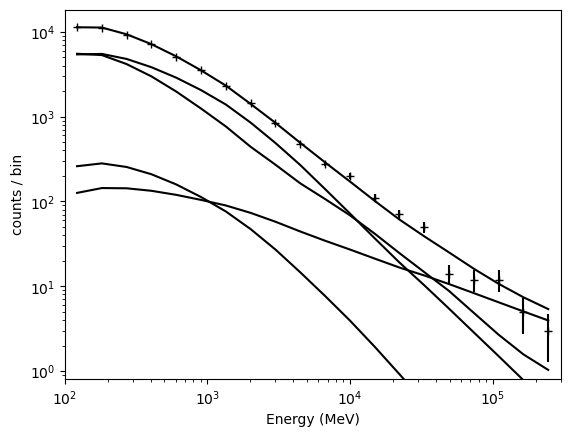

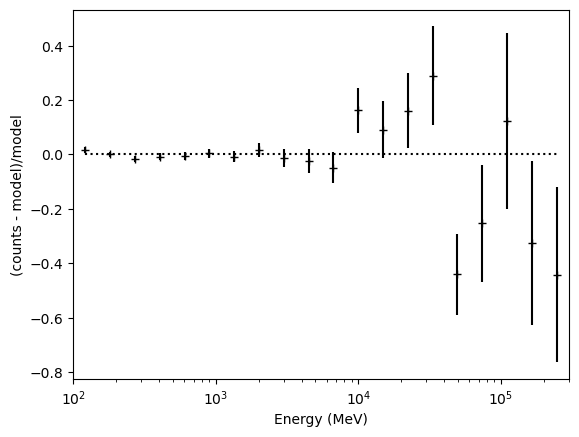

In [31]:
%matplotlib inline
like.plot()

In [32]:
print(likeobj.getRetCode())

0


In [33]:
import matplotlib.pyplot as plt
import numpy as np

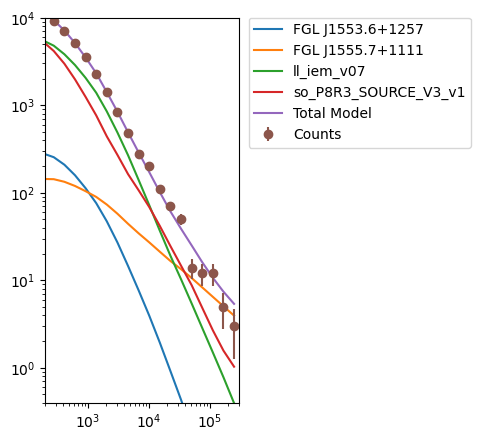

In [34]:
E = (like.energies[:-1] + like.energies[1:])/2.
# The 'energies' array are the endpoints so we take
# the midpoint of the bins.

plt.figure(figsize=(5,5))
plt.ylim((0.4,1e4))
plt.xlim((200,300000))
sum_model = np.zeros_like(like._srcCnts(like.sourceNames()[0]))

for sourceName in like.sourceNames():
    sum_model = sum_model + like._srcCnts(sourceName)
    plt.loglog(E,like._srcCnts(sourceName),label=sourceName[1:])

plt.loglog(E,sum_model,label='Total Model')
plt.errorbar(E,like._Nobs(),yerr=np.sqrt(like._Nobs()), fmt='o',label='Counts')
ax = plt.gca()
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.5, box.height])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

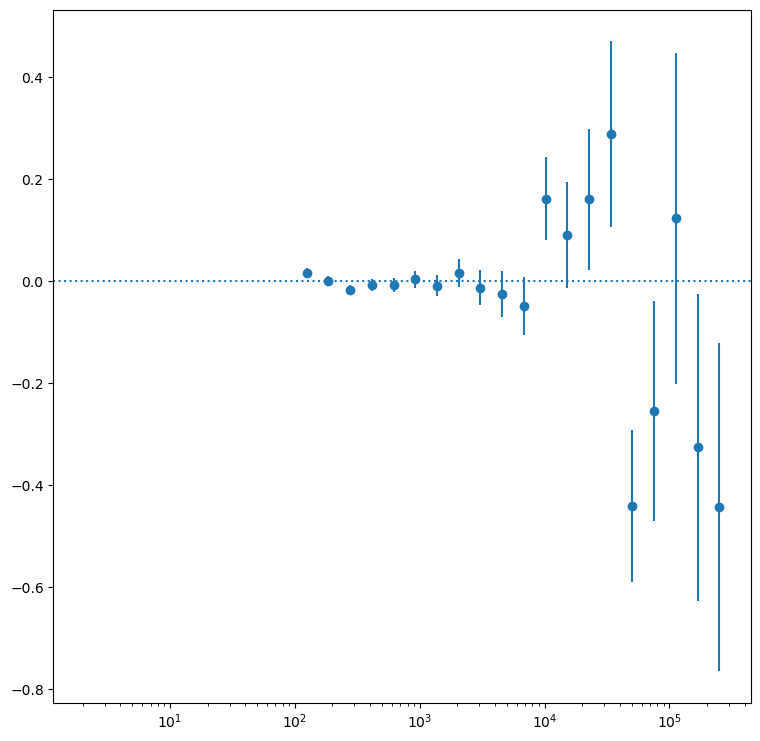

In [35]:
resid = (like._Nobs() - sum_model)/sum_model
resid_err = (np.sqrt(like._Nobs())/sum_model)
plt.figure(figsize=(9,9))
plt.xscale('log')
plt.errorbar(E,resid,yerr=resid_err,fmt='o')
plt.axhline(0.0,ls=':')
plt.show()

In [36]:
like.model['4FGL J1555.7+1111']

4FGL J1555.7+1111
   Spectrum: PowerLaw
4      Prefactor:  3.053e+00  1.991e-01  1.000e-04  1.000e+04 ( 1.000e-11)
5          Index:  1.608e+00  2.881e-02  0.000e+00  1.000e+01 (-1.000e+00)
6          Scale:  5.000e+02  0.000e+00  3.000e+01  5.000e+05 ( 1.000e+00) fixed

In [37]:
like.flux('4FGL J1555.7+1111',emin=100)

6.630383277249435e-08

In [38]:
like.fluxError('4FGL J1555.7+1111',emin=100)

4.361390890103163e-09

In [39]:
like.Ts('4FGL J1555.7+1111')

2843.8447748257313

In [40]:
np.sqrt(like.Ts('4FGL J1555.7+1111'))

53.32771113432238

In [41]:
like.logLike.writeXml('PG1553_fit.xml')

In [42]:
!mv *.xml ./data

## Create some TS Maps

In [43]:
!cp ./data/PG1553_fit.xml ./data/PG1553_fit_TSMap.xml

In [44]:
with open("./data/PG1553_fit_TSMap.xml") as file:
    file.read().replace("free=0", "free=1")

In [45]:
!cp ./data/PG1553_fit_TSMap.xml ./data/PG1553_fit_noPG1553.xml

In [46]:
my_apps.TsMap['statistic'] = "UNBINNED"
my_apps.TsMap['scfile'] = "./data/PG1553_SC.fits"
my_apps.TsMap['evfile'] = "./data/PG1553_filtered_gti.fits"
my_apps.TsMap['expmap'] = "./data/PG1553_expMap.fits"
my_apps.TsMap['expcube'] = "./data/PG1553_ltCube.fits"
my_apps.TsMap['srcmdl'] = "./data/PG1553_fit_TSMap.xml"
my_apps.TsMap['irfs'] = "CALDB"
my_apps.TsMap['optimizer'] = "DRMNGB"
my_apps.TsMap['outfile'] = "./data/PG1553_TSmap_resid.fits"
my_apps.TsMap['nxpix'] = 10
my_apps.TsMap['nypix'] = 10
my_apps.TsMap['binsz'] = 0.5
my_apps.TsMap['coordsys'] = "CEL"
my_apps.TsMap['xref'] = 238.929
my_apps.TsMap['yref'] = 11.1901
my_apps.TsMap['proj'] = 'STG'
my_apps.TsMap.run()

time -p gttsmap irfs="CALDB" evtype="INDEF" expcube=./data/PG1553_ltCube.fits srcmdl=./data/PG1553_fit_TSMap.xml statistic="UNBINNED" optimizer="DRMNGB" ftol=0.001 toltype="ABS" evfile=./data/PG1553_filtered_gti.fits evtable="EVENTS" scfile=./data/PG1553_SC.fits sctable="SC_DATA" expmap=./data/PG1553_expMap.fits cmap=none bexpmap=none wmap=none psfcorr=yes edisp_bins=0 outfile=./data/PG1553_TSmap_resid.fits nxpix=10 nypix=10 binsz=0.5 coordsys="CEL" xref=238.929 yref=11.1901 proj="STG" chatter=2 debug=no clobber=yes gui=no mode="ql"
....................!
real 969.62
user 966.77
sys 1.37


In [47]:
my_apps.TsMap['statistic'] = "UNBINNED"
my_apps.TsMap['scfile'] = "./data/PG1553_SC.fits"
my_apps.TsMap['evfile'] = "./data/PG1553_filtered_gti.fits"
my_apps.TsMap['expmap'] = "./data/PG1553_expMap.fits"
my_apps.TsMap['expcube'] = "./data/PG1553_ltCube.fits"
my_apps.TsMap['srcmdl'] = "./data/PG1553_fit_noPG1553.xml"
my_apps.TsMap['irfs'] = "CALDB"
my_apps.TsMap['optimizer'] = "DRMNGB"
my_apps.TsMap['outfile'] = "./data/PG1553_TSmap_noPG1553.fits"
my_apps.TsMap['nxpix'] = 10
my_apps.TsMap['nypix'] = 10
my_apps.TsMap['binsz'] = 0.5
my_apps.TsMap['coordsys'] = "CEL"
my_apps.TsMap['xref'] = 238.929
my_apps.TsMap['yref'] = 11.1901
my_apps.TsMap['proj'] = 'STG'
my_apps.TsMap.run()

time -p gttsmap irfs="CALDB" evtype="INDEF" expcube=./data/PG1553_ltCube.fits srcmdl=./data/PG1553_fit_noPG1553.xml statistic="UNBINNED" optimizer="DRMNGB" ftol=0.001 toltype="ABS" evfile=./data/PG1553_filtered_gti.fits evtable="EVENTS" scfile=./data/PG1553_SC.fits sctable="SC_DATA" expmap=./data/PG1553_expMap.fits cmap=none bexpmap=none wmap=none psfcorr=yes edisp_bins=0 outfile=./data/PG1553_TSmap_noPG1553.fits nxpix=10 nypix=10 binsz=0.5 coordsys="CEL" xref=238.929 yref=11.1901 proj="STG" chatter=2 debug=no clobber=yes gui=no mode="ql"
....................!
real 1000.83
user 998.05
sys 1.07


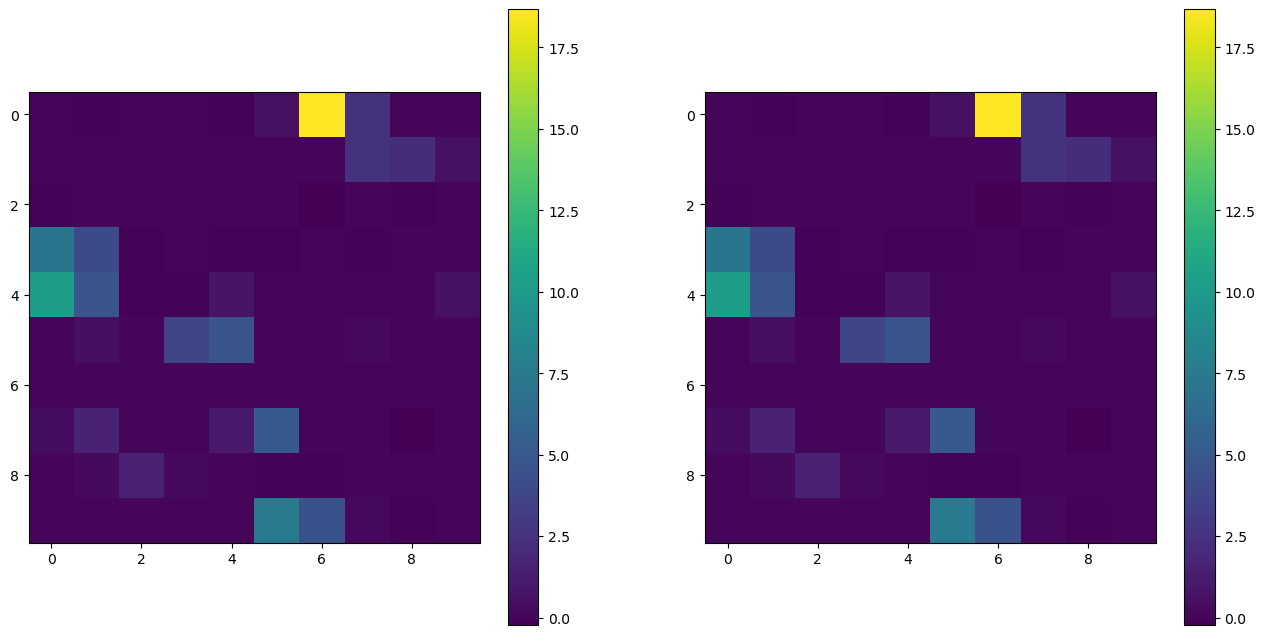

In [48]:
import astropy.io.fits as pyfits
residHDU = pyfits.open('./data/PG1553_TSmap_resid.fits')
sourceHDU = pyfits.open('./data/PG1553_TSmap_noPG1553.fits')
fig = plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(residHDU[0].data)
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(sourceHDU[0].data)
plt.colorbar()
plt.show()

In [49]:
np.max(sourceHDU[0].data)

18.674562

# Produce the Butterfly Plot

In [50]:
N0 = like.model['4FGL J1555.7+1111'].funcs['Spectrum'].getParam('Prefactor').value()
N0_err = like.model['4FGL J1555.7+1111'].funcs['Spectrum'].getParam('Prefactor').error()
gamma = like.model['4FGL J1555.7+1111'].funcs['Spectrum'].getParam('Index').value()
gamma_err = like.model['4FGL J1555.7+1111'].funcs['Spectrum'].getParam('Index').error()
E0 = like.model['4FGL J1555.7+1111'].funcs['Spectrum'].getParam('Scale').value()

In [51]:
freeParValues = []

for sourcename in like.sourceNames():
    for element in like.freePars(sourcename):
        freeParValues.append(element.getValue())

g_index = freeParValues.index(like.freePars('4FGL J1555.7+1111')[1].getValue())
cov_gg = like.covariance[g_index][g_index]

In [52]:
f = lambda E,N0,E0,gamma: N0*(E/E0)**(-1*gamma)
ferr = lambda E,F,N0,N0err,E0,cov_gg: F*np.sqrt(N0err**2/N0**2 + ((np.log(E/E0))**2)*cov_gg)

In [53]:
E = np.logspace(2,5,100)
F = f(E,N0,E0,gamma)
Ferr = ferr(E,F,N0,N0_err,E0,cov_gg)

In [ ]:
plt.figure(figsize=(8,8))
plt.xlabel('Energy [MeV]')
plt.ylabel(r'E$^2$ dN/dE [MeV s$^{-1}$ cm$^{-2}$]')
plt.loglog(E,E**2*(F+Ferr))
plt.loglog(E,E**2*(F-Ferr))
plt.plot(E,E**2*F)
plt.show()

In [ ]:
gc.collect()

1826403

: 